# 循环神经网络
## 序列模型
1. 定义：
    - 自然语言，音频，视频以及其他序列数据的模型
2. 类型：
    - 语音识别
    - 情感分类
    - 机器翻译
## 为什么序列模型不用CNN
1. 序列具有相关性
2. 序列输入长度不一致，输出长度不一致
## 循环神经网络
1. 类型：
    - 一对一：固定的输入到固定的输出，例如图像分类
    - 一对多：固定的输入到序列输出，例如图像转文字描述
    - 多对一：序列输入到固定输出，例如情感分析
    - 多对多：序列输入到序列输出，例如机器翻译，称之为编解码网格
    - 同步多对多：同步输入到同步输出，例如文本生成，视频每一帧的分类，称之为序列生成


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, LSTM
import numpy as np

data_dim = 16
timesteps = 8
num_classes = 10

# 期望输入数据的形状为 (batch_size, timesteps, data_dim)
model = Sequential()
model.add(LSTM(32, return_sequences=True, input_shape=(timesteps, data_dim)))
model.add(LSTM(32, return_sequences=True))
model.add(LSTM(32))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

# 生成随机数据
x_train = np.random.random((1000, timesteps, data_dim))
y_train = np.random.random((1000, num_classes))

# 生成随机验证数据
x_val = np.random.random((100, timesteps, data_dim))
y_val = np.random.random((100, num_classes))

# 训练模型
model.fit(x_train, y_train,
          batch_size=32, epochs=10,
          validation_data=(x_val, y_val))

score = model.evaluate(x_val, y_val, batch_size=32)
print("Test score:", score[0])

In [ ]:
import jieba

sent = '中文分词是文本处理不可或缺的一步！'

seg_list = jieba.cut(sent, cut_all=True)
print('全模式：', '/'.join(seg_list))

seg_list = jieba.cut(sent, cut_all=False)
print('精确模式：', '/'.join(seg_list))

seg_list = jieba.cut(sent)
print('默认精确模式：', '/'.join(seg_list))

seg_list = jieba.cut_for_search(sent)
print('搜索引擎模式', '/'.join(seg_list))

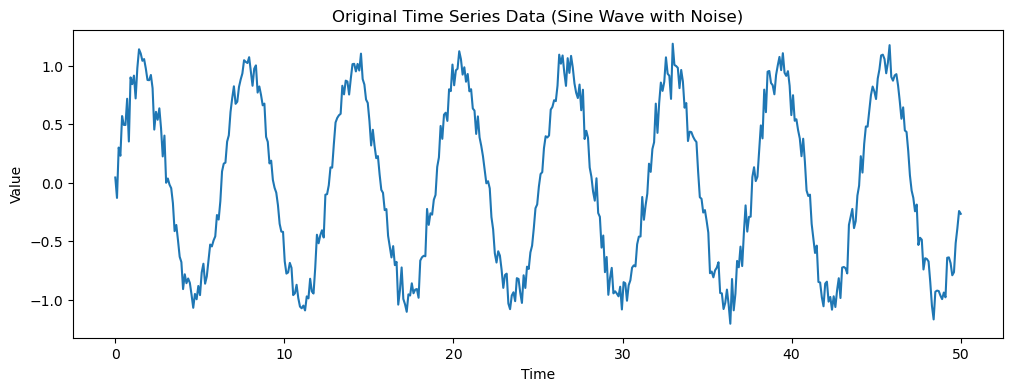

X 的形状: (490, 10, 1)
y 的形状: (490,)
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 50)                10400     
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 10,451
Trainable params: 10,451
Non-trainable params: 0
_________________________________________________________________
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 50)                10400     
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 10

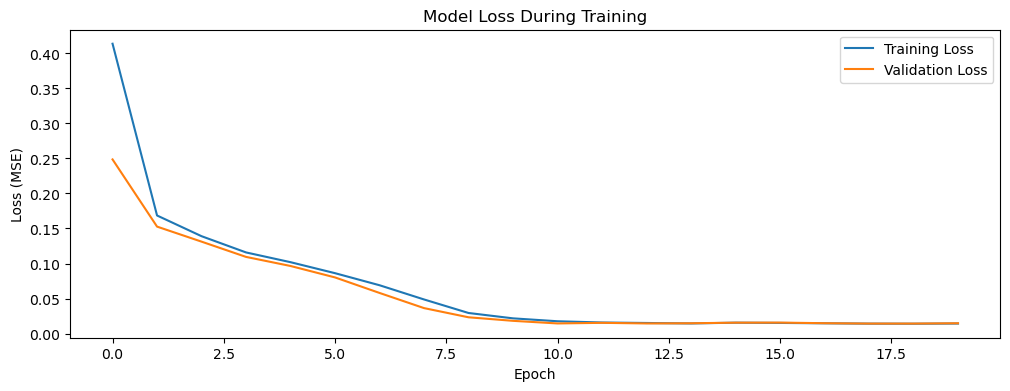

4/4 [==============================] - 0s 2ms/step


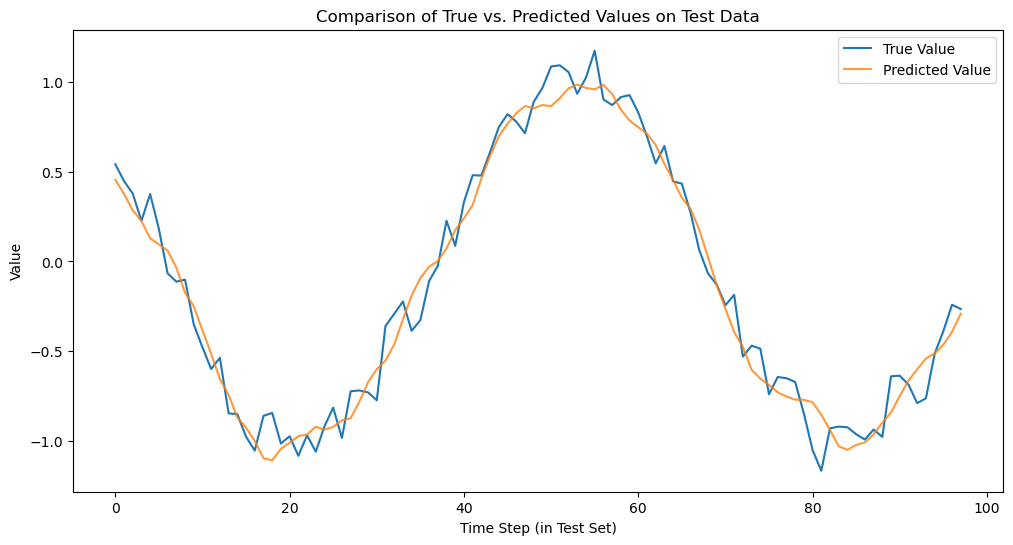

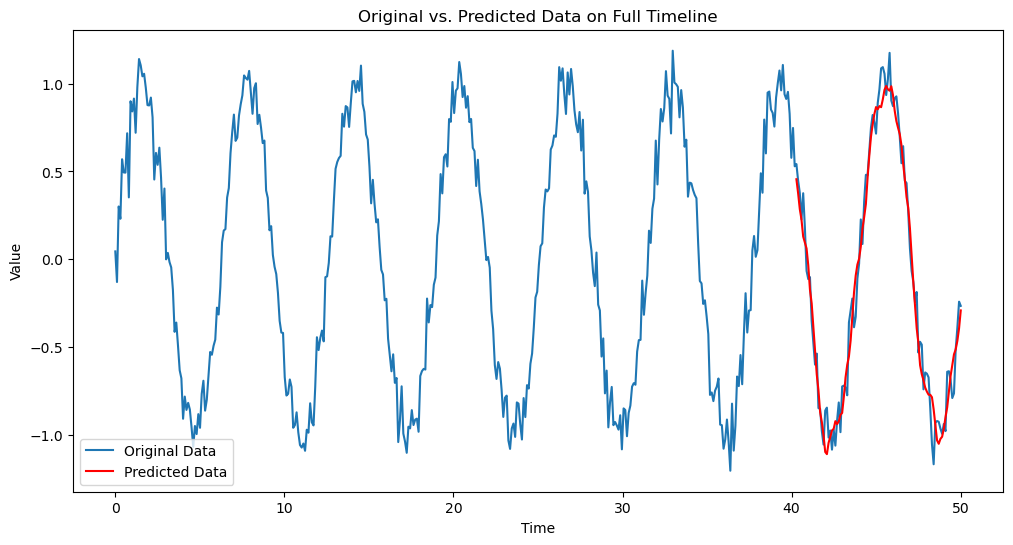

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ------------------------------------------------------
# 1. 准备数据 (Prepare Data)
# ------------------------------------------------------

# 创建一个时间轴，从 0 到 50，共 500 个点
time = np.linspace(0, 50, 500)
# 生成一个正弦波数据，加入一些随机噪声使其更接近真实世界
data = np.sin(time) + np.random.normal(0, 0.1, 500)

# 绘制原始数据，看看我们要预测的是什么
plt.figure(figsize=(12, 4))
plt.plot(time, data)
plt.title("Original Time Series Data (Sine Wave with Noise)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# ------------------------------------------------------
# 2. 创建序列 (Create Sequences using Sliding Window)
# ------------------------------------------------------

def create_sequences(data, window_size):
    """
    使用滑动窗口从时间序列数据中创建输入(X)和输出(y)序列。
    
    参数:
    data (np.array): 原始时间序列数据。
    window_size (int): 用于预测未来值的历史数据点数。
    
    返回:
    X (np.array): 输入序列，形状为 (样本数, window_size, 1)
    y (np.array): 输出序列，形状为 (样本数, 1)
    """
    X, y = [], []
    # 从第 window_size 个数据点开始循环
    for i in range(window_size, len(data)):
        # X 是从 i-window_size 到 i-1 的数据点 (历史数据)
        X.append(data[i-window_size:i])
        # y 是第 i 个数据点 (未来要预测的数据)
        y.append(data[i])
    
    # 将列表转换为 numpy 数组，并调整 X 的形状以适应 LSTM
    # LSTM 期望的输入形状是 (samples, time_steps, features)
    # 这里我们只有一个特征（数值本身），所以 features=1
    return np.array(X).reshape(-1, window_size, 1), np.array(y)

# 定义滑动窗口的大小，例如用过去 10 个时间点的数据来预测下一个
WINDOW_SIZE = 10

# 调用函数创建序列
X, y = create_sequences(data, WINDOW_SIZE)

# 打印数据形状，确认是否正确
print(f"X 的形状: {X.shape}")  # (样本数, 时间步长, 特征数) -> (490, 10, 1)
print(f"y 的形状: {y.shape}")  # (样本数,) -> (490,)

# ------------------------------------------------------
# 3. 构建模型 (Build the LSTM Model)
# ------------------------------------------------------

model = Sequential()

# 添加一个 LSTM 层
# units=50: 该层有 50 个神经元
# input_shape=(WINDOW_SIZE, 1): 输入数据的形状，与我们创建的 X 匹配
model.add(LSTM(units=50, input_shape=(WINDOW_SIZE, 1)))

# 添加一个全连接层（Dense Layer）作为输出层
# units=1: 因为我们要预测一个数值，所以输出层只有一个神经元
model.add(Dense(units=1))

# 编译模型
# optimizer='adam': 一种常用的优化算法，能自适应学习率
# loss='mean_squared_error': 均方误差，回归问题中常用的损失函数
model.compile(optimizer='adam', loss='mean_squared_error')

# 打印模型摘要
model.summary()

# ------------------------------------------------------
# 4. 训练模型 (Train the Model)
# ------------------------------------------------------

# 将数据集的前 80% 作为训练集，后 20% 作为测试集
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 训练模型
# X_train, y_train: 用于训练的数据
# epochs=20: 训练轮数，即整个数据集将被模型学习 20 次
# batch_size=32: 每次训练迭代中使用的样本数
# validation_data=(X_test, y_test): 在每个 epoch 结束后，用测试集评估模型性能
history = model.fit(X_train, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_data=(X_test, y_test))

# 绘制训练过程中的损失变化
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# ------------------------------------------------------
# 5. 进行预测 (Make Predictions)
# ------------------------------------------------------

# 使用测试集进行预测
y_pred = model.predict(X_test)

# 绘制真实值和预测值的对比图
plt.figure(figsize=(12, 6))

# 绘制测试集的真实值
plt.plot(y_test, label='True Value')

# 绘制模型的预测值
plt.plot(y_pred, label='Predicted Value', alpha=0.8)

plt.title('Comparison of True vs. Predicted Values on Test Data')
plt.xlabel('Time Step (in Test Set)')
plt.ylabel('Value')
plt.legend()
plt.show()

# 更直观的方式是将预测值绘制在原始数据的时间轴上
# 创建一个全零数组来存储所有预测值
predictions_plot = np.empty_like(data)
predictions_plot[:] = np.nan
# 将测试集的预测值放入正确的时间位置
predictions_plot[train_size + WINDOW_SIZE:] = y_pred.reshape(-1)

plt.figure(figsize=(12, 6))
plt.plot(time, data, label='Original Data')
plt.plot(time, predictions_plot, label='Predicted Data', color='red')
plt.title('Original vs. Predicted Data on Full Timeline')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()